1. Đang quét và nạp dữ liệu từ 11 file...
-> Tổng số dòng dữ liệu đưa vào huấn luyện: 81,723
-> Danh sách các lớp nhận diện (12 lớp): ['LSTM_DrDos_DNS_scaled', 'LSTM_DrDos_LDAP_scaled', 'LSTM_DrDos_MSSQL_scaled', 'LSTM_DrDos_NTP_scaled', 'LSTM_DrDos_NetBIOS_scaled', 'LSTM_DrDos_SNMP_scaled', 'LSTM_DrDos_SSDP_scaled', 'LSTM_DrDos_UDP_scaled', 'LSTM_Syn_scaled', 'LSTM_TFTP_scaled', 'LSTM_UDPLag_scaled', 'Normal']

2. Đang khởi tạo bộ não LSTM Đa lớp...
3. Bắt đầu quá trình huấn luyện...
Epoch 1/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6102 - loss: 1.3080 - val_accuracy: 0.7469 - val_loss: 0.8922 - learning_rate: 0.0010
Epoch 2/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7602 - loss: 0.8052 - val_accuracy: 0.8093 - val_loss: 0.6567 - learning_rate: 0.0010
Epoch 3/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8163 - loss: 0.6390 - val_accuracy: 0.8353 - val_loss: 0.5270 - learning_rate: 0.0010
Epoch 4/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step -

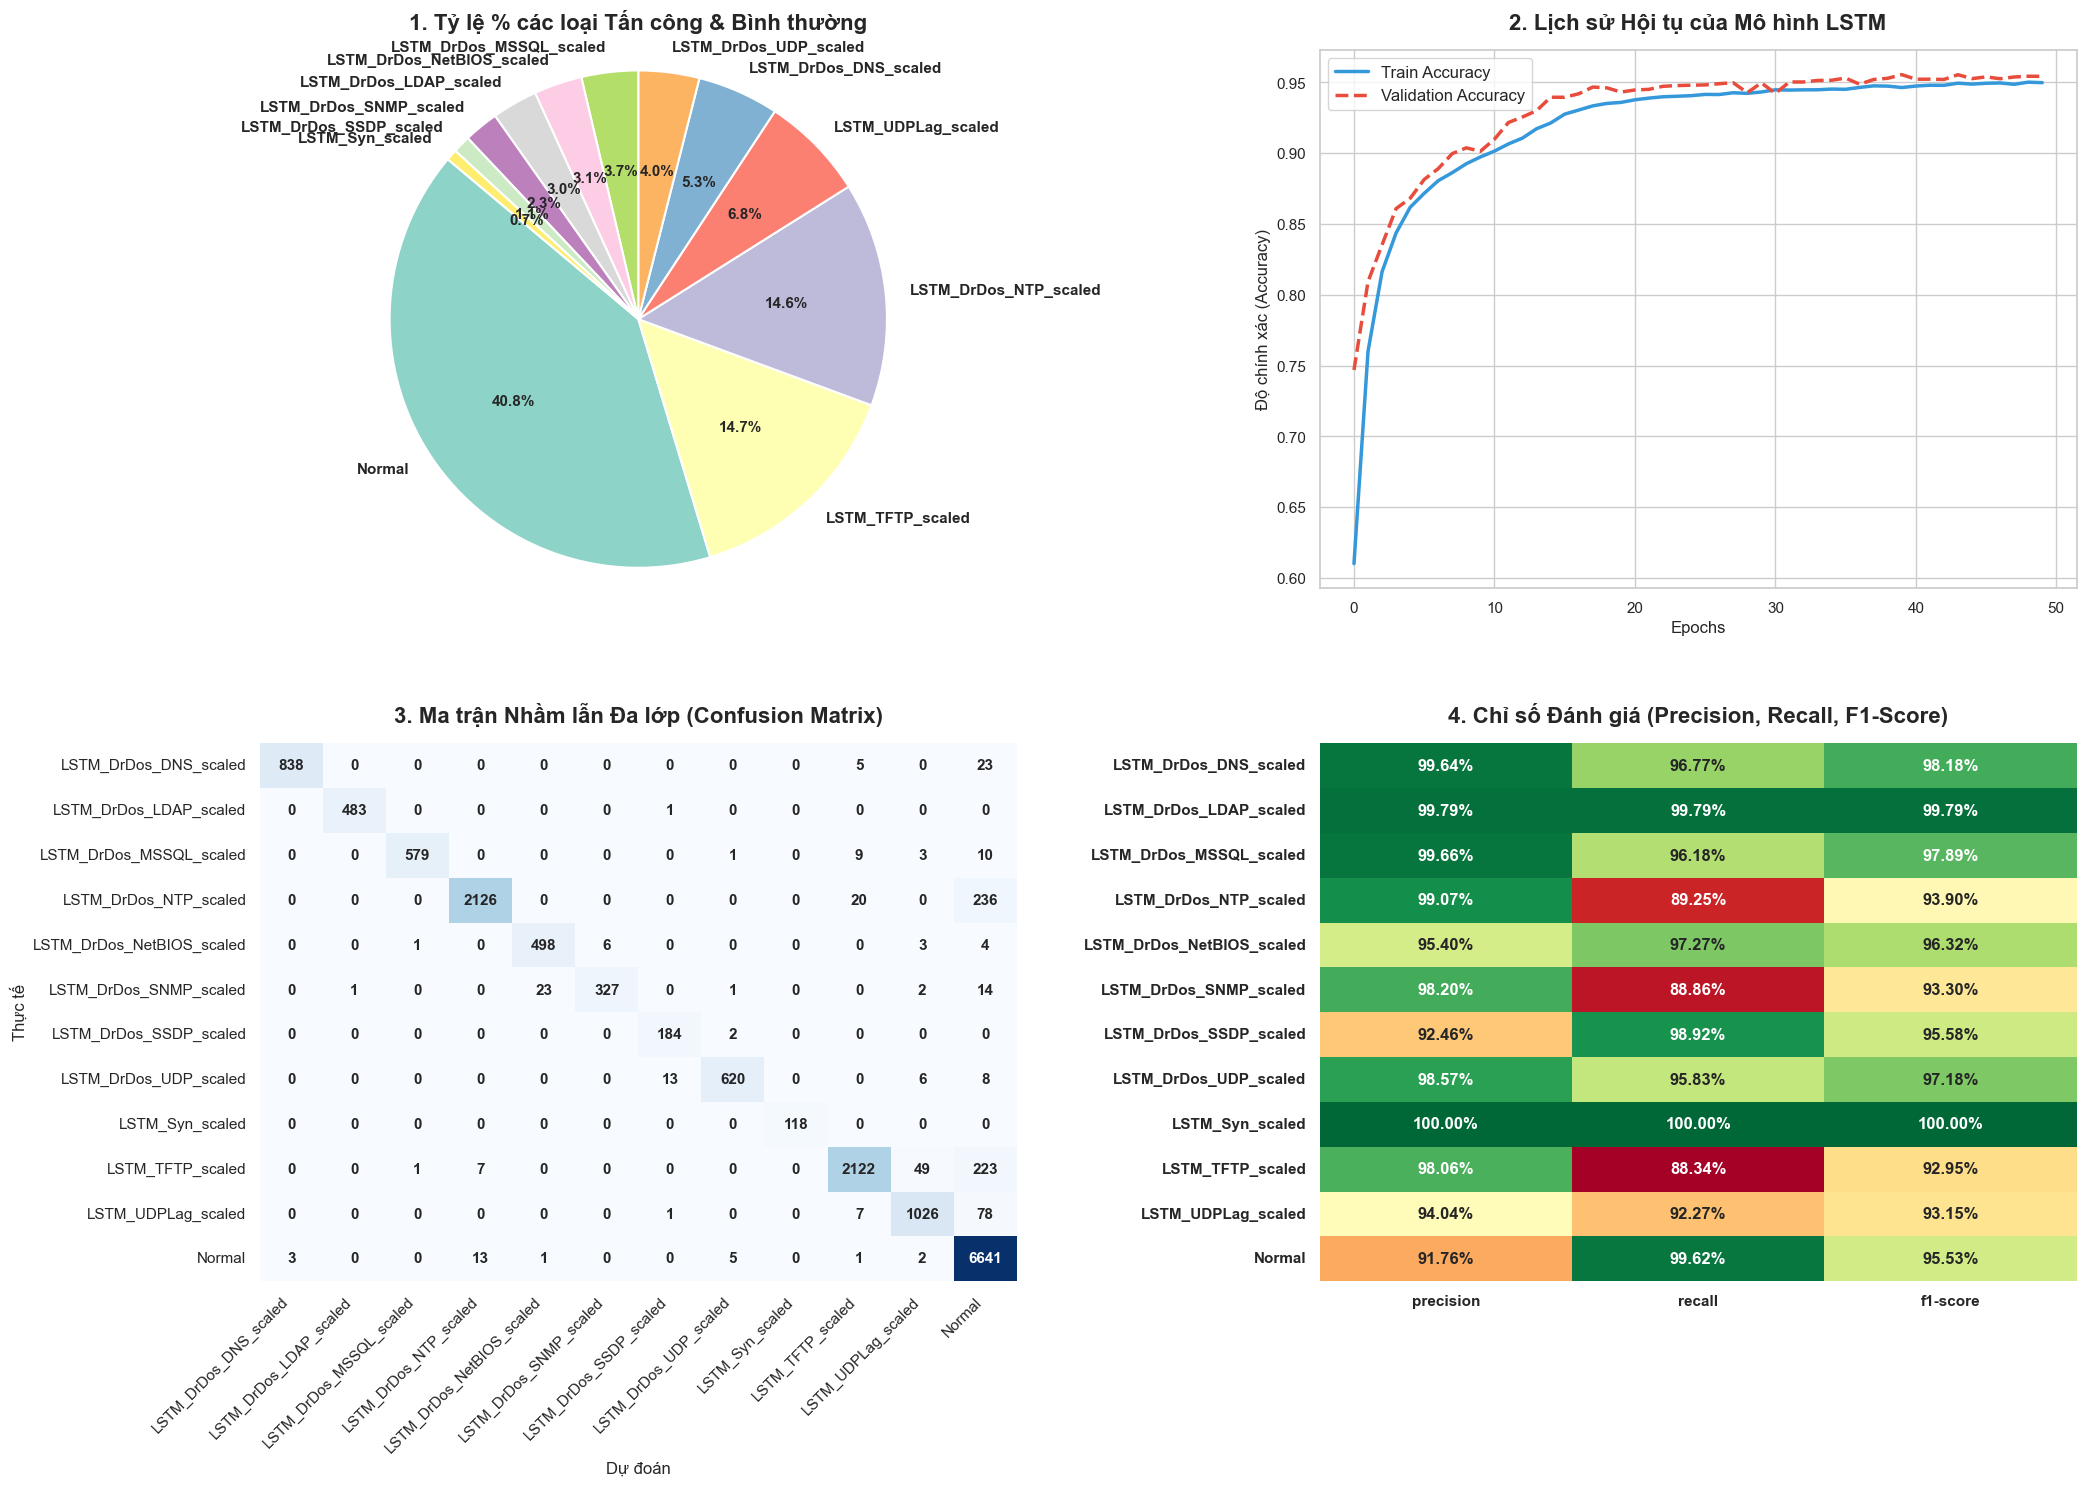

In [8]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TẮT CẢNH BÁO ĐỂ GIAO DIỆN SẠCH SẼ
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from keras import Sequential
from keras.layers import Input, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# PHẦN 1: TẢI, GỘP FILE & KHÔI PHỤC NHÃN
# ==========================================
folder_path = r"D:\detection_ddos\data\CSV-01-12\training\scaled\scaled\scaled"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"1. Đang quét và nạp dữ liệu từ {len(all_files)} file...")
df_list = []

for file in all_files:
    # Bóc tên file để khôi phục nhãn (VD: UDP.csv -> UDP)
    attack_name = os.path.basename(file).replace('.csv', '')
    
    temp_df = pd.read_csv(file)
    temp_df.columns = temp_df.columns.str.strip() 
    
    if 'Label' in temp_df.columns:
        # Nếu là 0/BENIGN thì giữ Normal, ngược lại gán tên file tấn công
        temp_df['Label'] = temp_df['Label'].apply(
            lambda x: 'Normal' if str(x).strip() in ['0', '0.0', 'BENIGN', 'Normal'] else attack_name
        )
        
        # Lấy mẫu 20.000 dòng/file để chống tràn RAM & Cân bằng dữ liệu
        if len(temp_df) > 20000:
            temp_df = temp_df.sample(n=20000, random_state=42)
            
        df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print(f"-> Tổng số dòng dữ liệu đưa vào huấn luyện: {len(df):,}")

# Mã hóa nhãn dạng text (UDP, SYN...) thành số nguyên (0, 1, 2...)
encoder = LabelEncoder()
df['Label_Encoded'] = encoder.fit_transform(df['Label'])
num_classes = len(encoder.classes_)

print(f"-> Danh sách các lớp nhận diện ({num_classes} lớp): {list(encoder.classes_)}")

# Chuẩn bị X, y và Reshape 3D cho LSTM
X = df.drop(columns=['Label', 'Label_Encoded']).values
y = df['Label_Encoded'].values
X_reshaped = X.reshape((X.shape[0], 1, X.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# PHẦN 2: XÂY DỰNG MÔ HÌNH LSTM ĐA LỚP
# ==========================================
print("\n2. Đang khởi tạo bộ não LSTM Đa lớp...")
model = Sequential([
    Input(shape=(1, X.shape[1])),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax') # Softmax chuyên dùng cho đa lớp
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# PHẦN 3: HUẤN LUYỆN TỐI ƯU
# ==========================================
print("3. Bắt đầu quá trình huấn luyện...")
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Lưu mô hình chuẩn bị cho báo cáo/triển khai
model.save(r"D:\detection_ddos\notebooks\ddos_multiclass_final.keras")
print("\n[OK] Đã lưu mô hình tại: ddos_multiclass_final.keras")

# ==========================================
# PHẦN 4: VẼ BIỂU ĐỒ BÁO CÁO (KAGGLE STYLE)
# ==========================================
print("\n4. Đang phân tích và xuất biểu đồ báo cáo...")
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(22, 16))

# --- BIỂU ĐỒ 1: TỶ LỆ DỮ LIỆU (PIE CHART) ---
plt.subplot(2, 2, 1)
label_counts = df['Label'].value_counts()
colors = sns.color_palette('Set3')[0:len(label_counts)]
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('1. Tỷ lệ % các loại Tấn công & Bình thường', fontsize=16, fontweight='bold', pad=15)
plt.axis('equal')

# --- BIỂU ĐỒ 2: LỊCH SỬ HUẤN LUYỆN ---
plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', lw=2.5, color='#3498DB')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', lw=2.5, color='#E74C3C', linestyle='--')
plt.title('2. Lịch sử Hội tụ của Mô hình LSTM', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.legend(fontsize=12)

# --- BIỂU ĐỒ 3: MA TRẬN NHẦM LẪN ---
plt.subplot(2, 2, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('3. Ma trận Nhầm lẫn Đa lớp (Confusion Matrix)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.ylabel('Thực tế', fontsize=12)
plt.xlabel('Dự đoán', fontsize=12)

# --- BIỂU ĐỒ 4: BÁO CÁO HEATMAP (%) ---
plt.subplot(2, 2, 4)
report = classification_report(y_test, y_pred, target_names=encoder.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Trích xuất Precision, Recall, F1 và nhân 100 để ra phần trăm
metrics_df = report_df.iloc[:-3, :-1] * 100

# Tạo mảng text có gắn chữ "%"
annot_labels = np.array([[f"{val:.2f}%" for val in row] for row in metrics_df.values])

sns.heatmap(metrics_df, annot=annot_labels, fmt='', cmap='RdYlGn', cbar=False,
            annot_kws={"size": 12, "weight": "bold"})
plt.title('4. Chỉ số Đánh giá (Precision, Recall, F1-Score)', fontsize=16, fontweight='bold', pad=15)
plt.yticks(rotation=0, fontsize=11, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')

# Căn chỉnh toàn bộ và hiển thị
plt.tight_layout(pad=4.0)
plt.show()